# Fixed stimulus order: optimize timing without changing the task sequence

This tutorial shows how to use `order=` when the order of events is imposed by the task itself. In that situation, optimization should improve the timing, not rewrite the sequence.

By the end, you will know how to:

1. compare unconstrained optimization against a task-imposed sequence,
2. fix the event order with `order`,
3. verify that optimization is acting on ITIs rather than on stimulus identities.


In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import neurodesign

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 110


## 1. Define the task-imposed sequence

Some paradigms already determine the order of events. For example, a training task may always present the same instructional sequence, or a calibration run may require a fixed alternation of conditions. In those cases, the design question is not *which order should I use?* but rather *which timing values work best for this order?*

`order` is the parameter that expresses that constraint at the `Experiment` level.

**Key parameter explained:**

- `order` is the full event-level sequence that every generated design must respect.
- Once `order` is supplied, the optimizer keeps that sequence fixed and only resamples timing-related quantities such as ITIs.
- `n_trials` must still match the length of the event-level order.


In [2]:
desired_order = [0, 1, 0, 1, 2, 3] * 3 + [0, 1]

common_kwargs = dict(
    TR=2,
    n_trials=len(desired_order),
    P=[0.25, 0.25, 0.25, 0.25],
    C=[[1, 0, -1, 0], [1, 0, 0, -1], [0, 1, -1, 0], [0, 1, 0, -1]],
    n_stimuli=4,
    rho=0.3,
    stim_duration=1,
    t_pre=0.5,
    t_post=2,
    ITImodel="exponential",
    ITImin=1,
    ITImax=4,
    ITImean=2.5,
)

print("Desired order:", desired_order)
print("Condition counts:", dict(Counter(desired_order)))


Desired order: [0, 1, 0, 1, 2, 3, 0, 1, 0, 1, 2, 3, 0, 1, 0, 1, 2, 3, 0, 1]
Condition counts: {0: 7, 1: 7, 2: 3, 3: 3}


## 2. What happens without `order`?

We first optimize the same experiment **without** fixing the sequence. This is the usual neurodesign behavior: the optimizer is free to change both the order and the timing.


In [3]:
exp_free = neurodesign.Experiment(**common_kwargs)

population_free = neurodesign.Optimisation(
    experiment=exp_free,
    R=[1, 0, 0],
    weights=[0, 0.5, 0.25, 0.25],
    preruncycles=10,
    cycles=25,
    folder="./",
    seed=100,
)

population_free.optimise()


c:\Users\vguigon\Desktop\Research_directory\Lab_SLD\neurodesign-plus\neurodesign\classes.py:679: UserWarning: the resolution is adjusted to be a multiple of the TR. New resolution: 0.1
  warnings.warn(
c:\Users\vguigon\Desktop\Research_directory\Lab_SLD\neurodesign-plus\neurodesign\classes.py:846: RuntimeWarning: divide by zero encountered in log
  res = (h - 1) * np.log(s) + h * np.log(l) - l * s - np.log(gamma(h))


Output()

Output()

Optimized order without constraint: [np.int64(0), 2, np.int64(3), np.int64(3), np.int64(1), np.int64(1), np.int64(2), np.int64(2), np.int64(0), 0, 3, 2, 0, 1, 2, 3, 1, np.int64(1), np.int64(0), np.int64(3)]
Matches desired order? False
Fd (detection efficiency): 1.0434
Fe (estimation efficiency): 0.0000
Fc (confounding score): 0.6976
Ff (frequency-balance score): 1.0000


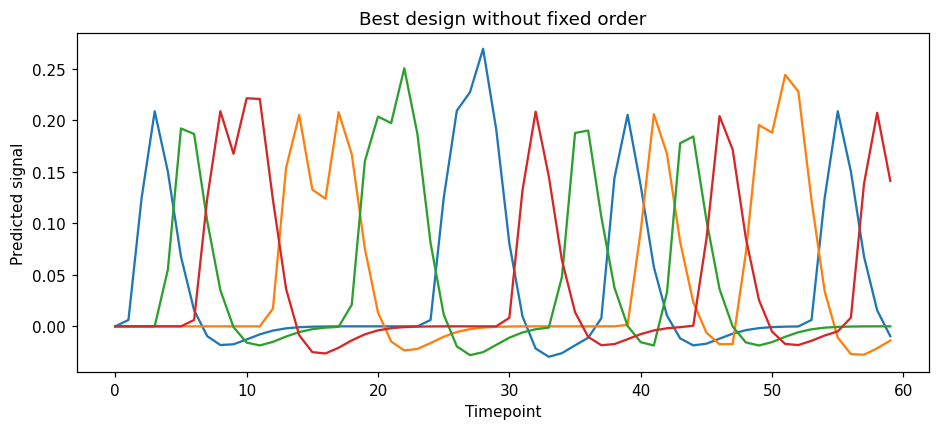

In [4]:
best_free = population_free.bestdesign
best_free.designmatrix()

print("Optimized order without constraint:", list(best_free.order))
print("Matches desired order?", list(best_free.order) == desired_order)
print(f"Fd (detection efficiency): {best_free.Fd:.4f}")
print(f"Fe (estimation efficiency): {best_free.Fe:.4f}")
print(f"Fc (confounding score): {best_free.Fc:.4f}")
print(f"Ff (frequency-balance score): {best_free.Ff:.4f}")

fig, ax = plt.subplots()
ax.plot(best_free.Xconv)
ax.set_title("Best design without fixed order")
ax.set_xlabel("Timepoint")
ax.set_ylabel("Predicted signal")
plt.show()


The optimized sequence will usually differ from the target one. That is expected: without `order`, the genetic algorithm is allowed to reorder events if doing so improves the objective.

This is useful when the task is still flexible. It is the wrong behavior when the task sequence is already fixed by the experimenter.


## 3. Fix the order and let optimization focus on timing

Now we add `order=desired_order` to the `Experiment`. The same optimization machinery can still search over ITIs, but the event identities remain locked.


In [5]:
exp_fixed = neurodesign.Experiment(order=desired_order, **common_kwargs)

population_fixed = neurodesign.Optimisation(
    experiment=exp_fixed,
    R=[1, 0, 0],
    weights=[0, 0.5, 0.25, 0.25],
    preruncycles=10,
    cycles=25,
    folder="./",
    seed=100,
)

population_fixed.optimise()


Output()

Output()

Optimized order with fixed-order constraint: [0, 1, 0, 1, 2, 3, 0, 1, 0, 1, 2, 3, 0, 1, 0, 1, 2, 3, 0, 1]
Matches desired order? True
First 10 ITIs: [0.  1.4 1.6 2.7 2.2 1.6 3.6 2.2 3.1 1.5]
Fd (detection efficiency): 1.0059
Fe (estimation efficiency): 0.0000
Fc (confounding score): 0.3368
Ff (frequency-balance score): 0.7333


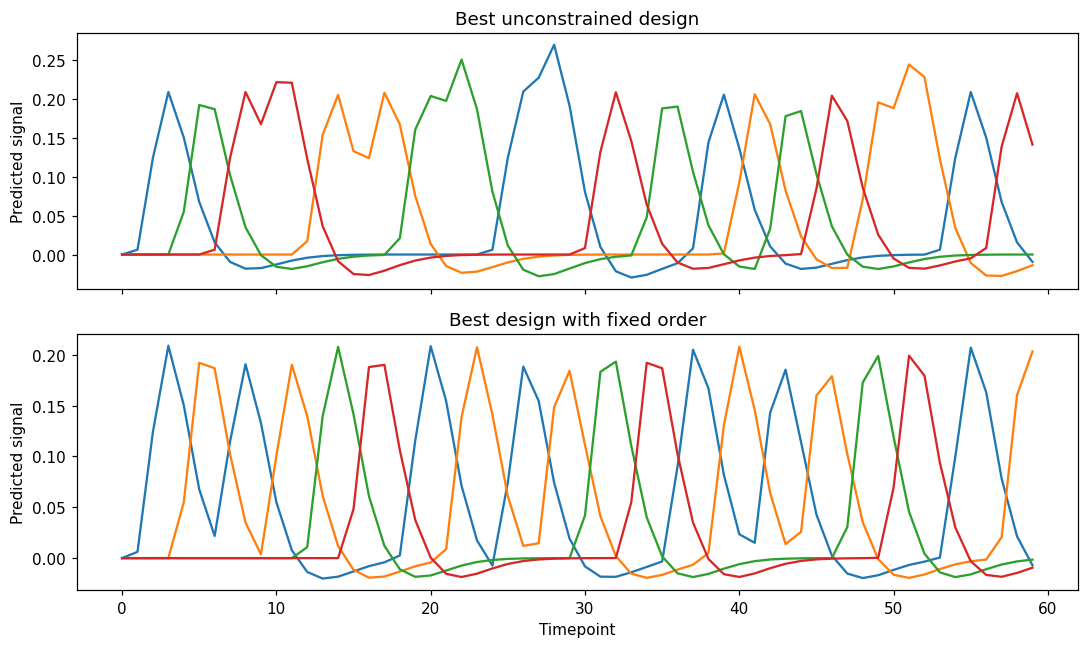

In [6]:
best_fixed = population_fixed.bestdesign
best_fixed.designmatrix()

print("Optimized order with fixed-order constraint:", list(best_fixed.order))
print("Matches desired order?", list(best_fixed.order) == desired_order)
print("First 10 ITIs:", np.round(best_fixed.ITI[:10], 2))
print(f"Fd (detection efficiency): {best_fixed.Fd:.4f}")
print(f"Fe (estimation efficiency): {best_fixed.Fe:.4f}")
print(f"Fc (confounding score): {best_fixed.Fc:.4f}")
print(f"Ff (frequency-balance score): {best_fixed.Ff:.4f}")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(best_free.Xconv)
axes[0].set_title("Best unconstrained design")
axes[1].plot(best_fixed.Xconv)
axes[1].set_title("Best design with fixed order")
axes[1].set_xlabel("Timepoint")
for ax in axes:
    ax.set_ylabel("Predicted signal")
plt.tight_layout()
plt.show()


## 4. Takeaway

Use `order` when the sequence is part of the paradigm rather than part of the optimization problem. The practical effect is simple:

- without `order`, neurodesign can change both the event identities and the timing,
- with `order`, neurodesign keeps the event sequence fixed and searches over timing only.

That makes `order` the right tool whenever your task logic is fixed but your ITIs are still open to optimization.
